In [1]:
# ==========================================
# Customer Segmentation Analysis
# Import Required Libraries
# ==========================================

# Data manipulation
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

# Model Saving
import joblib

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

# Display plots inside the notebook
%matplotlib inline

## Load the Dataset

In [2]:
# ==========================================
# Load and Inspect the Dataset
# ==========================================

# Load the dataset
df = pd.read_csv("Customer Loyalty History.csv")

# Display the first five rows
print("First 5 Rows:")
display(df.head())

# Display the shape of the dataset
print("\nDataset Shape:")
print(df.shape)

# Display dataset information
print("\nDataset Information:")
df.info()

# Display summary statistics
print("\nSummary Statistics:")
display(df.describe().T)

# Check for missing values
print("\nMissing Values:")
display(df.isnull().sum())

# Check for duplicate records
print("\nDuplicate Records:")
print(df.duplicated().sum())

First 5 Rows:


,Loyalty Number,Country,Province,City,Postal Code,Gender,Education,Salary,Marital Status,Loyalty Card,CLV,Enrollment Type,Enrollment Year,Enrollment Month,Cancellation Year,Cancellation Month
0,480934,Canada,Ontario,Toronto,M2Z 4K1,Female,Bachelor,83236.0,Married,Star,3839.14,Standard,2016,2,NaN,NaN
1,549612,Canada,Alberta,Edmonton,T3G 6Y6,Male,College,NaN,Divorced,Star,3839.61,Standard,2016,3,NaN,NaN
2,429460,Canada,British Columbia,Vancouver,V6E 3D9,Male,College,NaN,Single,Star,3839.75,Standard,2014,7,2018.0,1.0
3,608370,Canada,Ontario,Toronto,P1W 1K4,Male,College,NaN,Single,Star,3839.75,Standard,2013,2,NaN,NaN
4,530508,Canada,Quebec,Hull,J8Y 3Z5,Male,Bachelor,103495.0,Married,Star,3842.79,Standard,2014,10,NaN,NaN



Dataset Shape:
(16737, 16)

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 16737 entries, 0 to 16736
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Loyalty Number      16737 non-null  int64  
 1   Country             16737 non-null  str    
 2   Province            16737 non-null  str    
 3   City                16737 non-null  str    
 4   Postal Code         16737 non-null  str    
 5   Gender              16737 non-null  str    
 6   Education           16737 non-null  str    
 7   Salary              12499 non-null  float64
 8   Marital Status      16737 non-null  str    
 9   Loyalty Card        16737 non-null  str    
 10  CLV                 16737 non-null  float64
 11  Enrollment Type     16737 non-null  str    
 12  Enrollment Year     16737 non-null  int64  
 13  Enrollment Month    16737 non-null  int64  
 14  Cancellation Year   2067 non-null   float64
 15  Cancellation M

,count,mean,std,min,25%,50%,75%,max
Loyalty Number,16737.0,549735.880445,258912.132453,100018.00,326603.00,550434.00,772019.00,999986.00
Salary,12499.0,79245.609409,35008.297285,-58486.00,59246.50,73455.00,88517.50,407228.00
CLV,16737.0,7988.896536,6860.982280,1898.01,3980.84,5780.18,8940.58,83325.38
Enrollment Year,16737.0,2015.253211,1.979111,2012.00,2014.00,2015.00,2017.00,2018.00
Enrollment Month,16737.0,6.669116,3.398958,1.00,4.00,7.00,10.00,12.00
Cancellation Year,2067.0,2016.503145,1.380743,2013.00,2016.00,2017.00,2018.00,2018.00
Cancellation Month,2067.0,6.962748,3.455297,1.00,4.00,7.00,10.00,12.00



Missing Values:


Loyalty Number            0
Country                   0
Province                  0
City                      0
Postal Code               0
Gender                    0
Education                 0
Salary                 4238
Marital Status            0
Loyalty Card              0
CLV                       0
Enrollment Type           0
Enrollment Year           0
Enrollment Month          0
Cancellation Year     14670
Cancellation Month    14670
dtype: int64


Duplicate Records:
0


## Data Quality Assessment

The dataset contains **16,737 customer records** and **16 features**. Before performing any analysis, it is important to assess the quality of the data to identify potential issues that could affect the clustering results.

### Key Findings
- The dataset contains **no duplicate records**.
- The **Salary** column has missing values that require further investigation.
- The **Cancellation Year** and **Cancellation Month** columns contain a large number of missing values. These missing values are likely due to customers who have not cancelled their loyalty membership rather than errors in data collection.

The next step is to investigate these missing values and determine the most appropriate preprocessing strategy before building the customer segmentation model.

## Investigating Missing Values

Missing values do not always indicate poor data quality. In many real-world datasets, they can represent meaningful information.

In this dataset:
- Missing values in the **Salary** column may be due to unavailable or unreported customer income.
- Missing values in **Cancellation Year** and **Cancellation Month** may indicate that a customer has not cancelled their loyalty membership.

The following analysis investigates these missing values before deciding on an appropriate preprocessing strategy.

In [3]:
# ==========================================
# Investigate Missing Values
# ==========================================

missing_values = df.isnull().sum().sort_values(ascending=False)

print("Missing Values by Column:")
display(missing_values)

Missing Values by Column:


Cancellation Month    14670
Cancellation Year     14670
Salary                 4238
Loyalty Number            0
City                      0
Postal Code               0
Province                  0
Country                   0
Education                 0
Gender                    0
Marital Status            0
Loyalty Card              0
Enrollment Type           0
CLV                       0
Enrollment Month          0
Enrollment Year           0
dtype: int64

In [4]:
# Display only columns with missing values

missing_data = missing_values[missing_values > 0]

print("Columns Containing Missing Values:")
display(missing_data)

Columns Containing Missing Values:


Cancellation Month    14670
Cancellation Year     14670
Salary                 4238
dtype: int64

In [5]:
# Check the relationship between cancellation fields

df[['Cancellation Year', 'Cancellation Month']].head(10)

,Cancellation Year,Cancellation Month
0,NaN,NaN
1,NaN,NaN
2,2018.0,1.0
3,NaN,NaN
4,NaN,NaN
5,NaN,NaN
6,NaN,NaN
7,NaN,NaN
8,NaN,NaN
9,NaN,NaN


## Findings from Missing Value Investigation

The missing value analysis revealed three columns with missing data:

- **Salary** contains 4,238 missing values that require preprocessing before model training.
- **Cancellation Year** and **Cancellation Month** contain 14,670 missing values each.

Further inspection shows that the missing values in the cancellation columns occur together, indicating that these customers have not cancelled their loyalty membership. Therefore, these missing values represent valid customer status rather than data quality issues and should not be treated as random missing data.

## Visualizing Missing Values

To better understand the extent of missing data, we visualize the number of missing values in each column.

### Check for Missing Values

In [6]:
# Count missing values in each column
missing_values = df.isnull().sum()
print(missing_values)

Loyalty Number            0
Country                   0
Province                  0
City                      0
Postal Code               0
Gender                    0
Education                 0
Salary                 4238
Marital Status            0
Loyalty Card              0
CLV                       0
Enrollment Type           0
Enrollment Year           0
Enrollment Month          0
Cancellation Year     14670
Cancellation Month    14670
dtype: int64


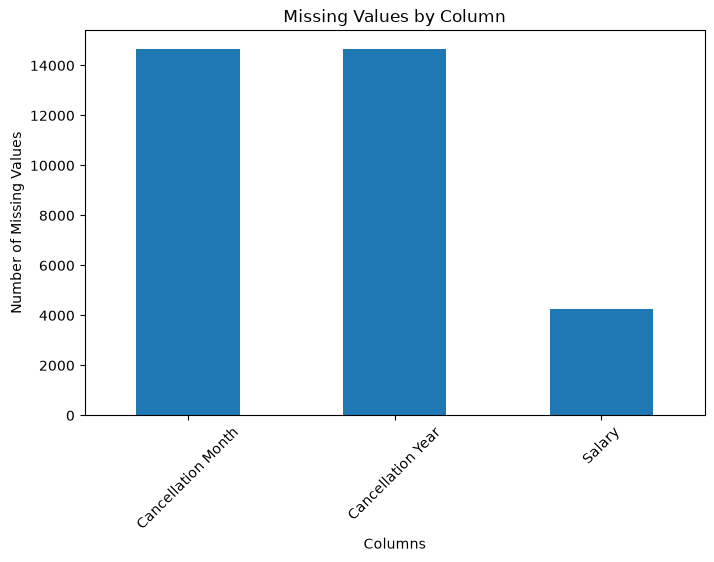

In [7]:
# ==========================================
# Visualize Missing Values
# ==========================================

missing_data.plot(kind='bar', figsize=(8,5))

plt.title("Missing Values by Column")
plt.xlabel("Columns")
plt.ylabel("Number of Missing Values")
plt.xticks(rotation=45)

plt.show()

# Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) is performed to better understand the characteristics of the customer data, identify patterns, detect potential outliers, and examine relationships between variables.

The insights gained from this analysis will guide feature selection and preprocessing for the customer segmentation model.

In [8]:
# ==========================================
# Identify Numerical and Categorical Features
# ==========================================

numerical_features = df.select_dtypes(include=['int64', 'float64']).columns
categorical_features = df.select_dtypes(include=['object']).columns

print("Numerical Features:")
print(list(numerical_features))

print("\nCategorical Features:")
print(list(categorical_features))

Numerical Features:
['Loyalty Number', 'Salary', 'CLV', 'Enrollment Year', 'Enrollment Month', 'Cancellation Year', 'Cancellation Month']

Categorical Features:
['Country', 'Province', 'City', 'Postal Code', 'Gender', 'Education', 'Marital Status', 'Loyalty Card', 'Enrollment Type']


## Distribution of Numerical Features

Understanding the distribution of numerical variables helps identify skewness, unusual values, and the overall spread of the data. This information is particularly useful when selecting an appropriate preprocessing strategy, such as handling missing values or applying feature scaling.

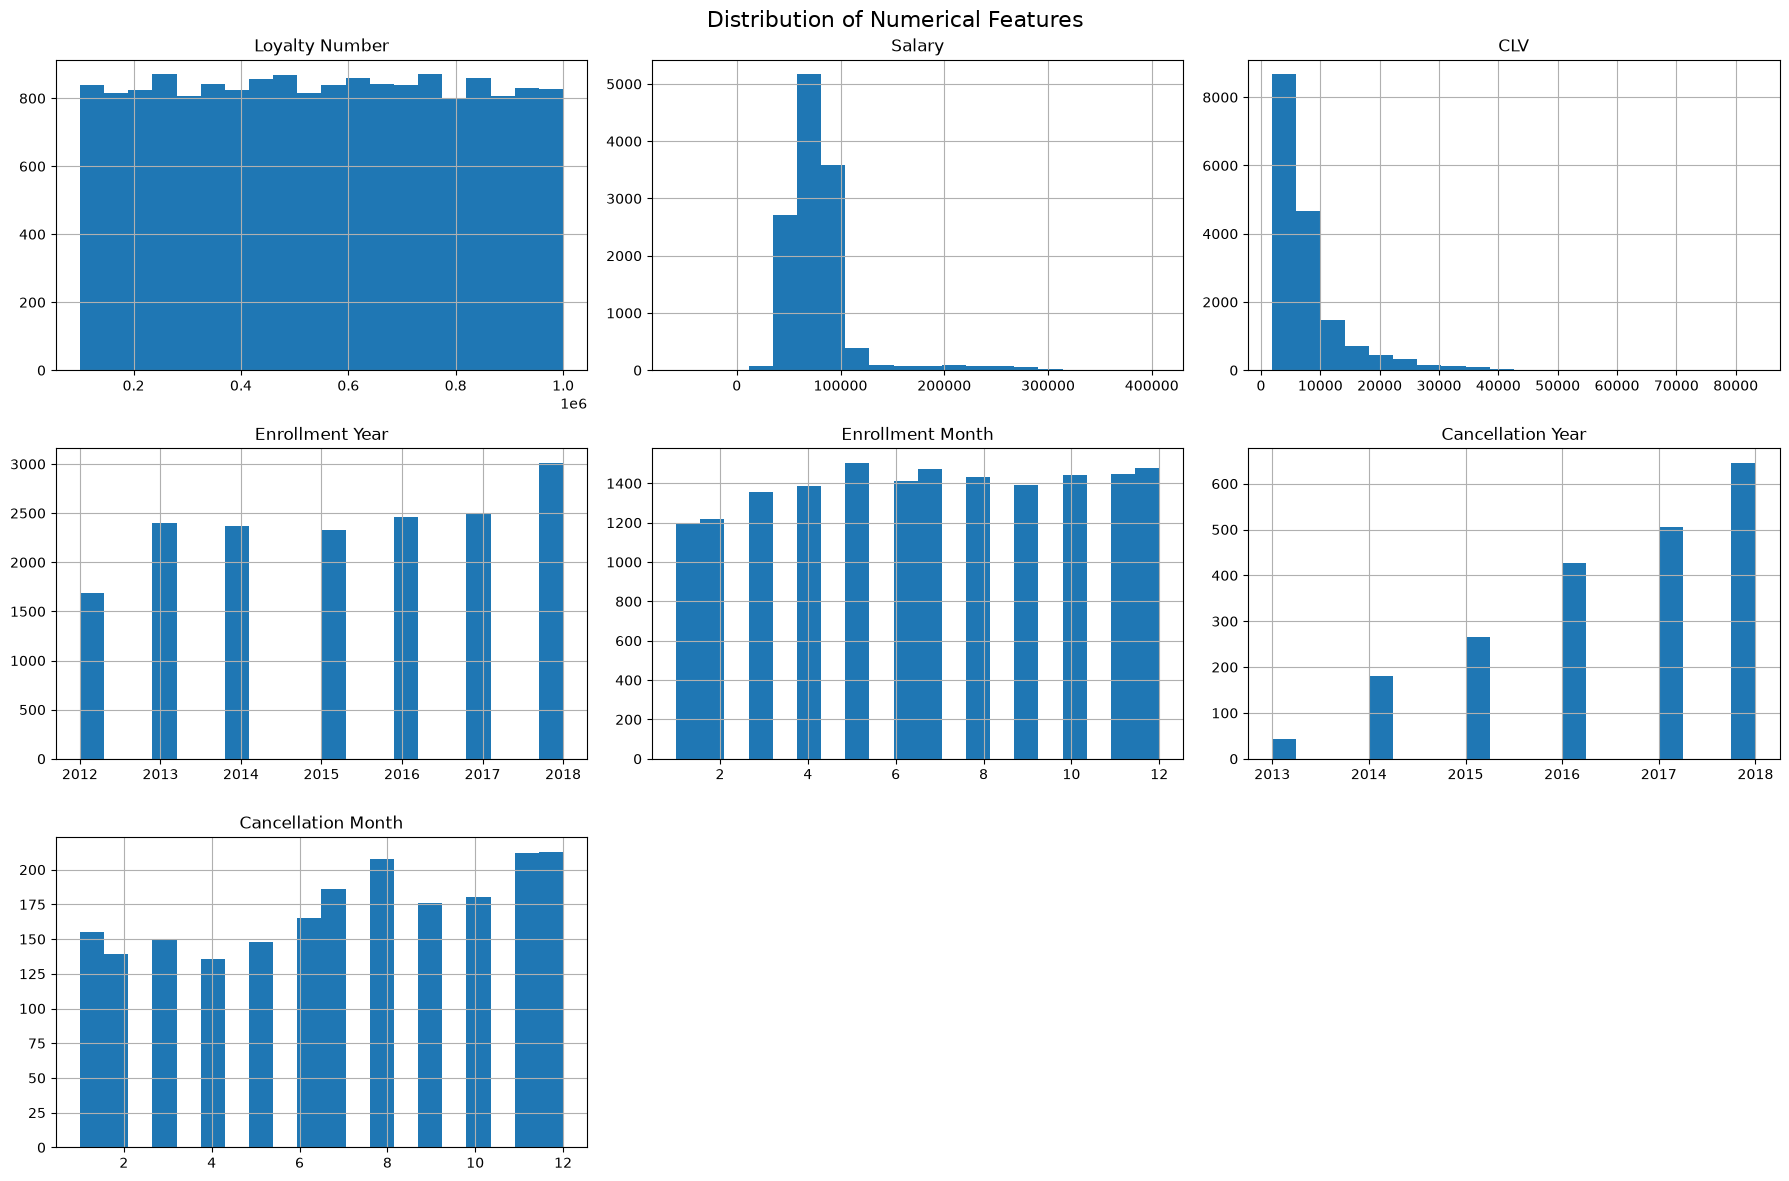

In [9]:
# ==========================================
# Distribution of Numerical Features
# ==========================================

df[numerical_features].hist(figsize=(18, 12), bins=20)

plt.suptitle("Distribution of Numerical Features", fontsize=16)

plt.tight_layout()

plt.show()

## Observations from Numerical Feature Distributions

The distribution of the numerical features provides several important insights:

- The **Salary** variable is positively skewed, with a small number of customers earning significantly higher salaries than the majority. Therefore, the median is considered a more appropriate method for imputing missing salary values.
- **Customer Lifetime Value (CLV)** is also positively skewed, indicating that while most customers have relatively low lifetime value, a smaller group contributes substantially more value to the business.
- The **Enrollment Year** and **Enrollment Month** variables show expected distributions across the recorded periods.
- Missing values in the cancellation-related variables are consistent with customers who have not cancelled their loyalty membership and therefore require special handling rather than standard imputation.

## Distribution of Categorical Features

This section explores the categorical variables to understand the distribution of customers across different demographic and loyalty-related categories.

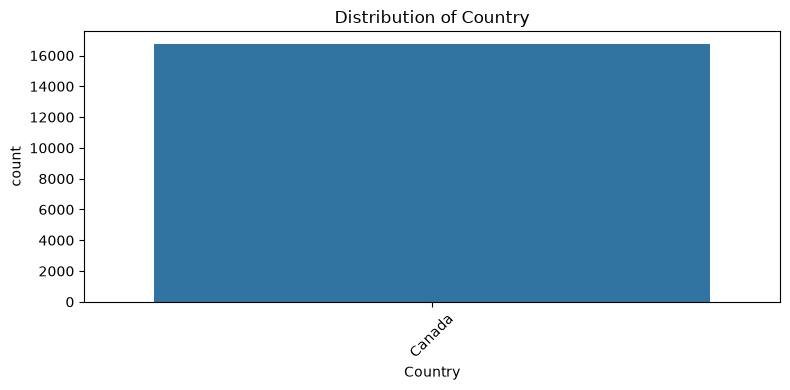

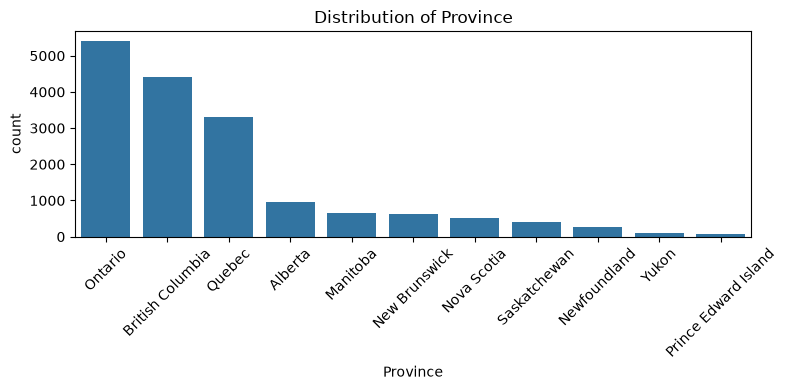

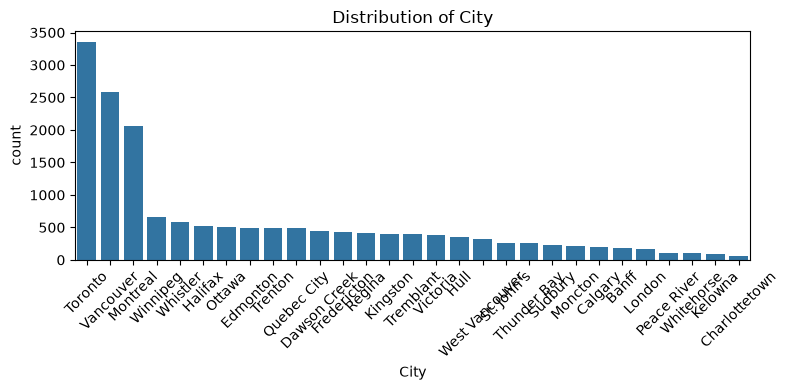

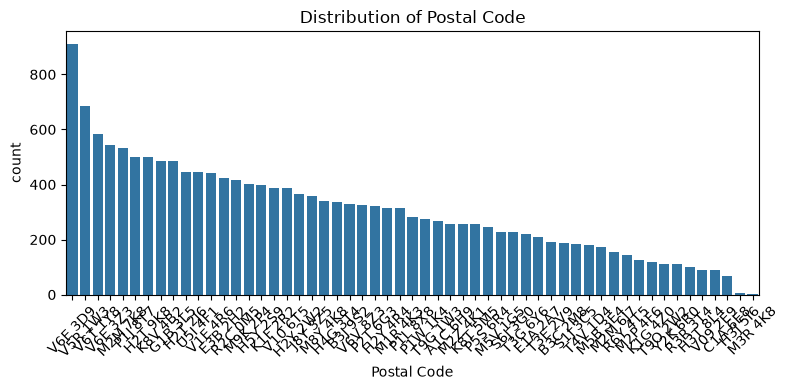

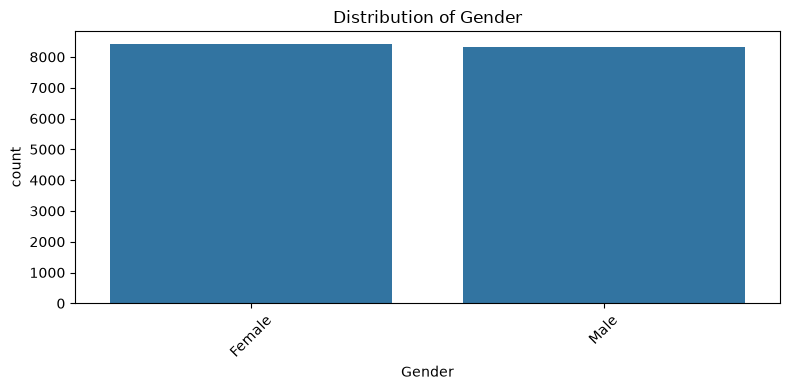

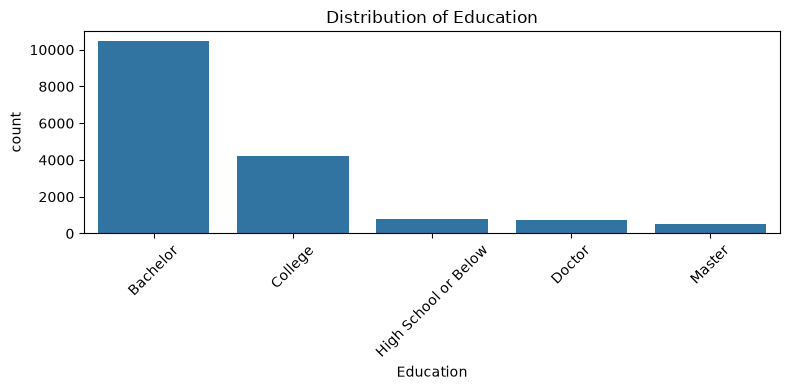

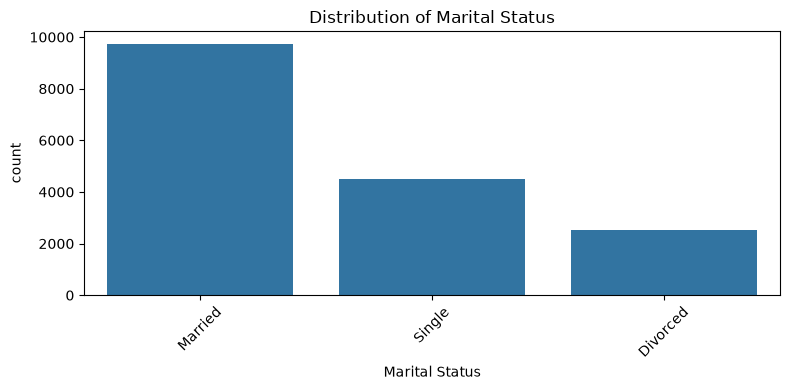

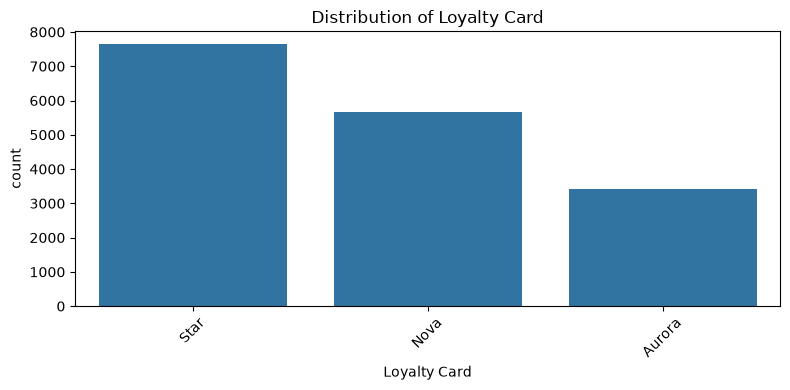

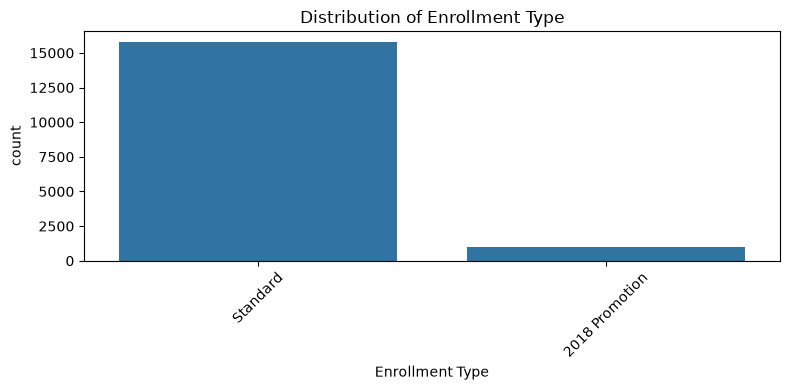

In [10]:
# ==========================================
# Distribution of Categorical Features
# ==========================================

for column in categorical_features:
    plt.figure(figsize=(8, 4))

    sns.countplot(
        data=df,
        x=column,
        order=df[column].value_counts().index
    )

    plt.title(f"Distribution of {column}")
    plt.xticks(rotation=45)

    plt.tight_layout()
    plt.show()

## Observations from Categorical Feature Distributions

The categorical variables provide valuable insights into the composition of the customer base:

- All customers are located in **Canada**, indicating that the dataset represents a single-country customer population.
- **Ontario**, **British Columbia**, and **Quebec** contain the highest number of customers, while the remaining provinces contribute relatively smaller customer populations.
- Customer distribution across cities is uneven, with **Toronto**, **Vancouver**, and **Montreal** accounting for the largest share of customers.
- The gender distribution is nearly balanced, suggesting no significant gender imbalance within the dataset.
- Most customers hold a **Bachelor's degree**, followed by those with a **College** education.
- **Married** customers represent the largest marital status group.
- The **Star** loyalty card is the most common membership tier, followed by **Nova** and **Aurora**.
- Most customers enrolled through the **Standard** enrollment program, while relatively few joined through the **2018 Promotion** campaign.

These findings provide a better understanding of the customer population and help identify variables that may contribute to meaningful customer segmentation.

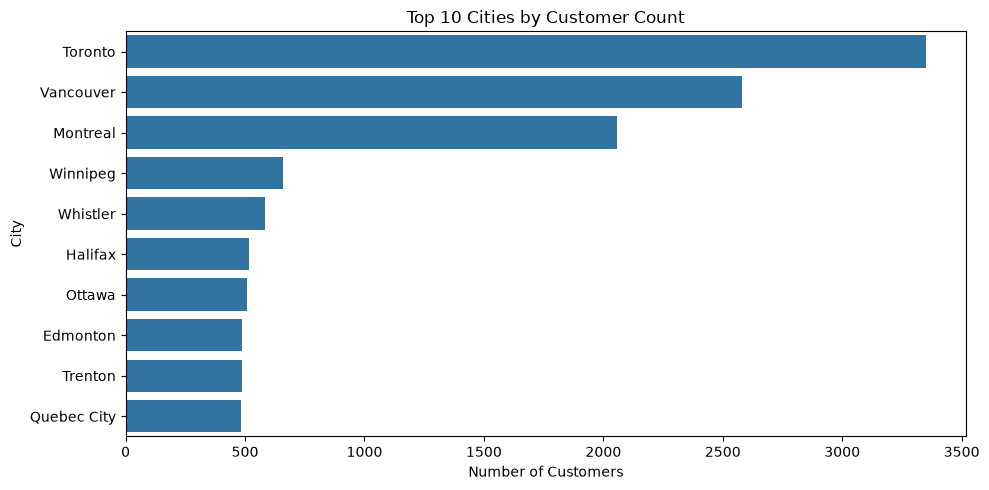

In [11]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    y="City",
    order=df["City"].value_counts().head(10).index
)

plt.title("Top 10 Cities by Customer Count")
plt.xlabel("Number of Customers")
plt.ylabel("City")

plt.tight_layout()
plt.show()

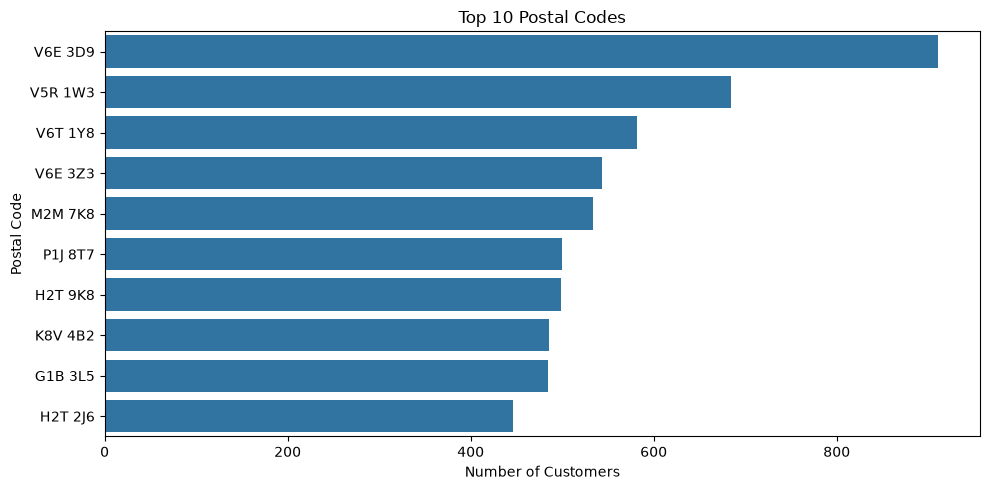

In [12]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    y="Postal Code",
    order=df["Postal Code"].value_counts().head(10).index
)

plt.title("Top 10 Postal Codes")
plt.xlabel("Number of Customers")
plt.ylabel("Postal Code")

plt.tight_layout()
plt.show()

# Data Preprocessing

Data preprocessing prepares the dataset for machine learning by handling missing values, removing irrelevant features, encoding categorical variables, and scaling numerical variables.

Proper preprocessing is essential because clustering algorithms such as K-Means are sensitive to feature scales and data quality.

## Handling Missing Values

Based on the exploratory data analysis:

- Missing values in **Salary** will be imputed using the **median**, as the distribution is positively skewed.
- Missing values in **Cancellation Year** and **Cancellation Month** are retained during this stage because they indicate customers who have not cancelled their loyalty membership rather than missing observations.

In [13]:
# ==========================================
# Handle Missing Values
# ==========================================

# Fill missing Salary values using the median
df["Salary"] = df["Salary"].fillna(df["Salary"].median())

print("Remaining Missing Values:")
display(df.isnull().sum())

Remaining Missing Values:


Loyalty Number            0
Country                   0
Province                  0
City                      0
Postal Code               0
Gender                    0
Education                 0
Salary                    0
Marital Status            0
Loyalty Card              0
CLV                       0
Enrollment Type           0
Enrollment Year           0
Enrollment Month          0
Cancellation Year     14670
Cancellation Month    14670
dtype: int64

## Feature Selection

Not every variable in the dataset contributes meaningful information for customer segmentation.

Several columns are excluded because they are identifiers, contain only a single category, or have extremely high cardinality.

### Excluded Features
- Loyalty Number
- Country
- Postal Code
- Cancellation Year
- Cancellation Month

The remaining variables capture customer demographics, loyalty characteristics, geographic information, and customer value, making them suitable candidates for clustering.

In [14]:
# ==========================================
# Select Features for Clustering
# ==========================================

selected_features = [
    "Province",
    "City",
    "Gender",
    "Education",
    "Salary",
    "Marital Status",
    "Loyalty Card",
    "CLV",
    "Enrollment Type",
    "Enrollment Year",
    "Enrollment Month"
]

df_selected = df[selected_features]

print("Selected Features:")
display(df_selected.head())

Selected Features:


,Province,City,Gender,Education,Salary,Marital Status,Loyalty Card,CLV,Enrollment Type,Enrollment Year,Enrollment Month
0,Ontario,Toronto,Female,Bachelor,83236.0,Married,Star,3839.14,Standard,2016,2
1,Alberta,Edmonton,Male,College,73455.0,Divorced,Star,3839.61,Standard,2016,3
2,British Columbia,Vancouver,Male,College,73455.0,Single,Star,3839.75,Standard,2014,7
3,Ontario,Toronto,Male,College,73455.0,Single,Star,3839.75,Standard,2013,2
4,Quebec,Hull,Male,Bachelor,103495.0,Married,Star,3842.79,Standard,2014,10


## Encoding Categorical Variables

Machine learning algorithms require numerical input. Therefore, categorical variables are converted into numerical representations using **One-Hot Encoding**.

Unlike Label Encoding, One-Hot Encoding does not introduce an artificial ordinal relationship between categories, making it more suitable for clustering algorithms such as K-Means.

In [15]:
# ==========================================
# One-Hot Encode Categorical Variables
# ==========================================

categorical_cols = [
    "Province",
    "City",
    "Gender",
    "Education",
    "Marital Status",
    "Loyalty Card",
    "Enrollment Type"
]

df_encoded = pd.get_dummies(
    df_selected,
    columns=categorical_cols,
    drop_first=False
)

print("Dataset Shape After Encoding:")
print(df_encoded.shape)

display(df_encoded.head())

Dataset Shape After Encoding:
(16737, 59)


,Salary,CLV,Enrollment Year,Enrollment Month,Province_Alberta,Province_British Columbia,Province_Manitoba,Province_New Brunswick,Province_Newfoundland,Province_Nova Scotia,...,Education_High School or Below,Education_Master,Marital Status_Divorced,Marital Status_Married,Marital Status_Single,Loyalty Card_Aurora,Loyalty Card_Nova,Loyalty Card_Star,Enrollment Type_2018 Promotion,Enrollment Type_Standard
0,83236.0,3839.14,2016,2,False,False,False,False,False,False,...,False,False,False,True,False,False,False,True,False,True
1,73455.0,3839.61,2016,3,True,False,False,False,False,False,...,False,False,True,False,False,False,False,True,False,True
2,73455.0,3839.75,2014,7,False,True,False,False,False,False,...,False,False,False,False,True,False,False,True,False,True
3,73455.0,3839.75,2013,2,False,False,False,False,False,False,...,False,False,False,False,True,False,False,True,False,True
4,103495.0,3842.79,2014,10,False,False,False,False,False,False,...,False,False,False,True,False,False,False,True,False,True


## Feature Scaling

The numerical values in the dataset have different ranges. Since K-Means clustering relies on Euclidean distance, features with larger numerical values can dominate the clustering process.

To ensure that each feature contributes equally, the dataset is standardized using **StandardScaler**, which transforms each feature to have a mean of approximately 0 and a standard deviation of 1.

In [16]:
# ==========================================
# Feature Scaling
# ==========================================

# Initialize the scaler
scaler = StandardScaler()

# Scale the encoded dataset
X_scaled = scaler.fit_transform(df_encoded)

# Convert back to a DataFrame for easier inspection
X_scaled = pd.DataFrame(
    X_scaled,
    columns=df_encoded.columns
)

print("Scaled Dataset Shape:")
print(X_scaled.shape)

display(X_scaled.head())

Scaled Dataset Shape:
(16737, 59)


,Salary,CLV,Enrollment Year,Enrollment Month,Province_Alberta,Province_British Columbia,Province_Manitoba,Province_New Brunswick,Province_Newfoundland,Province_Nova Scotia,...,Education_High School or Below,Education_Master,Marital Status_Divorced,Marital Status_Married,Marital Status_Single,Loyalty Card_Aurora,Loyalty Card_Nova,Loyalty Card_Star,Enrollment Type_2018 Promotion,Enrollment Type_Standard
0,0.179752,-0.604852,0.377347,-1.373732,-0.247898,-0.598031,-0.202294,-0.198748,-0.125125,-0.178712,...,-0.221388,-0.176924,-0.420817,0.848092,-0.604939,-0.507607,-0.715871,1.091589,-0.24817,0.24817
1,-0.142453,-0.604784,0.377347,-1.079515,4.033912,-0.598031,-0.202294,-0.198748,-0.125125,-0.178712,...,-0.221388,-0.176924,2.376330,-1.179117,-0.604939,-0.507607,-0.715871,1.091589,-0.24817,0.24817
2,-0.142453,-0.604763,-0.633238,0.097351,-0.247898,1.672154,-0.202294,-0.198748,-0.125125,-0.178712,...,-0.221388,-0.176924,-0.420817,-1.179117,1.653059,-0.507607,-0.715871,1.091589,-0.24817,0.24817
3,-0.142453,-0.604763,-1.138531,-1.373732,-0.247898,-0.598031,-0.202294,-0.198748,-0.125125,-0.178712,...,-0.221388,-0.176924,-0.420817,-1.179117,1.653059,-0.507607,-0.715871,1.091589,-0.24817,0.24817
4,0.847121,-0.604320,-0.633238,0.980001,-0.247898,-0.598031,-0.202294,-0.198748,-0.125125,-0.178712,...,-0.221388,-0.176924,-0.420817,0.848092,-0.604939,-0.507607,-0.715871,1.091589,-0.24817,0.24817


In [17]:
# ==========================================
# Verify Scaling
# ==========================================

print("Mean of scaled features (first 10):")
display(X_scaled.mean().head(10))

print("\nStandard deviation of scaled features (first 10):")
display(X_scaled.std().head(10))

Mean of scaled features (first 10):


Salary                      -7.960015e-17
CLV                          3.396273e-17
Enrollment Year             -1.442142e-14
Enrollment Month            -1.952857e-17
Province_Alberta            -2.037764e-17
Province_British Columbia   -1.069826e-16
Province_Manitoba           -2.674565e-17
Province_New Brunswick       3.056646e-17
Province_Newfoundland       -3.226459e-17
Province_Nova Scotia        -4.500062e-17
dtype: float64


Standard deviation of scaled features (first 10):


Salary                       1.00003
CLV                          1.00003
Enrollment Year              1.00003
Enrollment Month             1.00003
Province_Alberta             1.00003
Province_British Columbia    1.00003
Province_Manitoba            1.00003
Province_New Brunswick       1.00003
Province_Newfoundland        1.00003
Province_Nova Scotia         1.00003
dtype: float64

## Feature Scaling Results

The scaling process was successfully completed.

Verification of the transformed data shows that:

- The mean of each feature is approximately **0**.
- The standard deviation of each feature is approximately **1**.

This confirms that all variables are on a comparable scale, ensuring that no single feature disproportionately influences the Euclidean distance calculations used by the K-Means clustering algorithm.

# 7.1 Choosing the Optimal Number of Clusters (Elbow Method)

# Model Development

The objective of this stage is to build a customer segmentation model using the K-Means clustering algorithm.

Before training the final model, it is necessary to determine an appropriate number of clusters. The Elbow Method provides a visual technique for identifying the point where adding more clusters yields diminishing improvements.

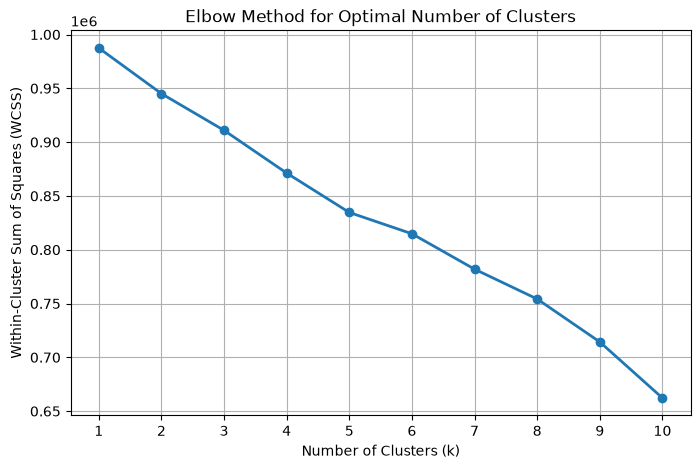

In [18]:
# ==========================================
# Elbow Method
# ==========================================

wcss = []

k_values = range(1, 11)

for k in k_values:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)

    wcss.append(kmeans.inertia_)

# Plot the Elbow Curve
plt.figure(figsize=(8, 5))

plt.plot(
    k_values,
    wcss,
    marker='o',
    linewidth=2
)

plt.title("Elbow Method for Optimal Number of Clusters")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Within-Cluster Sum of Squares (WCSS)")

plt.xticks(k_values)

plt.grid(True)

plt.show()

## Elbow Method Results

The Elbow Method was used to estimate the optimal number of clusters by plotting the Within-Cluster Sum of Squares (WCSS) against different values of *k*.

The curve shows a noticeable change in slope around **five clusters**, suggesting that this may be a suitable number of customer segments. However, because the elbow is not sharply defined, an additional evaluation metric is required.

To validate the choice of *k*, the **Silhouette Score** will be computed for different numbers of clusters.

# Silhouette Analysis

,Number of Clusters,Silhouette Score
0,2,0.033243
1,3,0.046001
2,4,0.060675
3,5,0.097903
4,6,0.076285
5,7,0.113265
6,8,0.111809
7,9,0.145650
8,10,0.179282


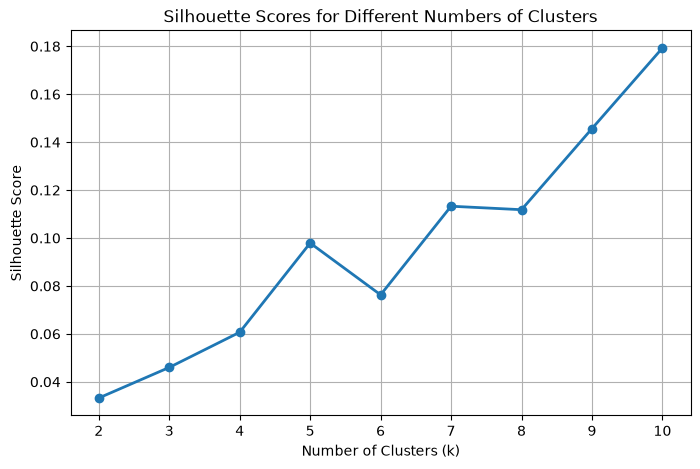

In [19]:
# ==========================================
# Silhouette Score Analysis
# ==========================================

from sklearn.metrics import silhouette_score

silhouette_scores = []

k_values = range(2, 11)

for k in k_values:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    cluster_labels = kmeans.fit_predict(X_scaled)

    score = silhouette_score(X_scaled, cluster_labels)

    silhouette_scores.append(score)

# Display Results
silhouette_df = pd.DataFrame({
    "Number of Clusters": list(k_values),
    "Silhouette Score": silhouette_scores
})

display(silhouette_df)

# Plot
plt.figure(figsize=(8,5))

plt.plot(
    k_values,
    silhouette_scores,
    marker='o',
    linewidth=2
)

plt.title("Silhouette Scores for Different Numbers of Clusters")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")

plt.xticks(k_values)
plt.grid(True)

plt.show()

## Silhouette Score Results

The Silhouette Score was calculated for cluster sizes ranging from two to ten.

Although the highest Silhouette Score was obtained at **10 clusters**, the Elbow Method suggested that **5 clusters** represents a reasonable balance between cluster compactness and model simplicity.

Since customer segmentation aims to produce interpretable and actionable groups rather than maximizing a single evaluation metric, **five clusters** were selected for the final K-Means model.

Future work may compare additional cluster sizes to determine whether they offer improved business value.

# Train the Final K-Means Model

## Training the Final K-Means Model

Based on the combined evaluation of the Elbow Method and the Silhouette Score, the final K-Means model is trained using **five clusters**.

Each customer will be assigned to one of these clusters for further analysis and interpretation.

In [20]:
# ==========================================
# Train Final K-Means Model
# ==========================================

# Initialize the model
final_kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

# Train the model
cluster_labels = final_kmeans.fit_predict(X_scaled)

# Add cluster labels to the original dataset
df["Cluster"] = cluster_labels

print("Cluster Assignment Complete!")

# Display first few rows
display(df.head())

Cluster Assignment Complete!


,Loyalty Number,Country,Province,City,Postal Code,Gender,Education,Salary,Marital Status,Loyalty Card,CLV,Enrollment Type,Enrollment Year,Enrollment Month,Cancellation Year,Cancellation Month,Cluster
0,480934,Canada,Ontario,Toronto,M2Z 4K1,Female,Bachelor,83236.0,Married,Star,3839.14,Standard,2016,2,NaN,NaN,1
1,549612,Canada,Alberta,Edmonton,T3G 6Y6,Male,College,73455.0,Divorced,Star,3839.61,Standard,2016,3,NaN,NaN,0
2,429460,Canada,British Columbia,Vancouver,V6E 3D9,Male,College,73455.0,Single,Star,3839.75,Standard,2014,7,2018.0,1.0,4
3,608370,Canada,Ontario,Toronto,P1W 1K4,Male,College,73455.0,Single,Star,3839.75,Standard,2013,2,NaN,NaN,1
4,530508,Canada,Quebec,Hull,J8Y 3Z5,Male,Bachelor,103495.0,Married,Star,3842.79,Standard,2014,10,NaN,NaN,3


Cluster
0    2404
1    5404
2     518
3    3936
4    4475
Name: count, dtype: int64

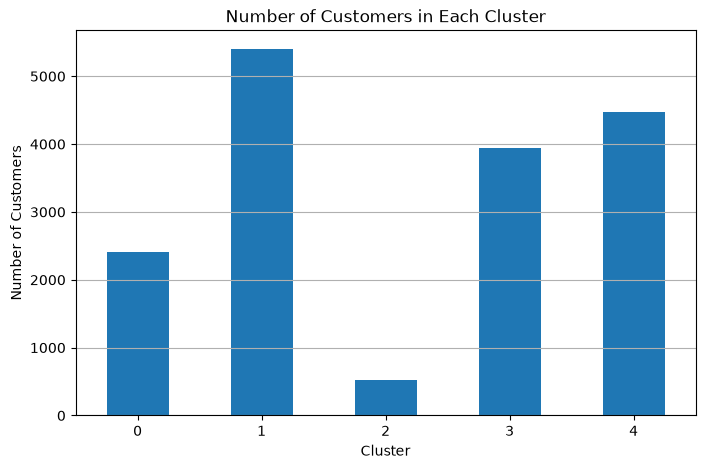

In [21]:
# ==========================================
# Number of Customers in Each Cluster
# ==========================================

cluster_counts = df["Cluster"].value_counts().sort_index()

display(cluster_counts)

plt.figure(figsize=(8,5))

cluster_counts.plot(
    kind="bar"
)

plt.title("Number of Customers in Each Cluster")
plt.xlabel("Cluster")
plt.ylabel("Number of Customers")

plt.xticks(rotation=0)

plt.grid(axis="y")

plt.show()

## Cluster Distribution

The final K-Means model assigned customers into five distinct clusters.

Most clusters contain several thousand customers, indicating that the segmentation is reasonably balanced. However, one cluster contains a relatively small number of customers, suggesting the presence of a specialized customer segment.

The next stage is to profile each cluster by examining customer demographics, income, customer lifetime value (CLV), loyalty card type, and enrollment characteristics.

## Cluster Profiling

To understand the characteristics of each customer segment, summary statistics are calculated for the numerical variables within each cluster.

This analysis helps identify differences in customer income, customer lifetime value, and enrollment characteristics across the clusters.

In [22]:
# ==========================================
# Numerical Profile of Each Cluster
# ==========================================

numerical_columns = [
    "Salary",
    "CLV",
    "Enrollment Year",
    "Enrollment Month"
]

cluster_profile = (
    df.groupby("Cluster")[numerical_columns]
      .mean()
      .round(2)
)

print("Cluster Profile (Numerical Features)")
display(cluster_profile)

Cluster Profile (Numerical Features)


,Salary,CLV,Enrollment Year,Enrollment Month
Cluster,,,,
0,76299.19,7878.05,2015.22,6.72
1,77717.19,7913.75,2015.25,6.68
2,76674.65,7983.30,2015.19,6.97
3,78472.68,8159.86,2015.27,6.68
4,78167.66,7989.46,2015.27,6.59


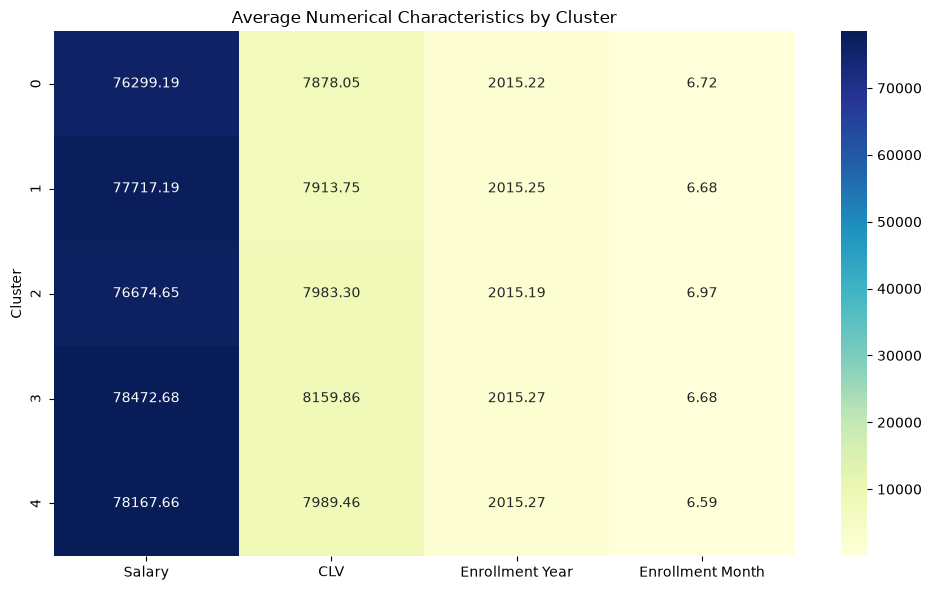

In [23]:
# ==========================================
# Heatmap of Cluster Characteristics
# ==========================================

plt.figure(figsize=(10, 6))

sns.heatmap(
    cluster_profile,
    annot=True,
    cmap="YlGnBu",
    fmt=".2f"
)

plt.title("Average Numerical Characteristics by Cluster")

plt.tight_layout()

plt.show()

## Categorical Profile of Customer Clusters

In addition to numerical characteristics, the dominant categorical attributes of each cluster are analyzed. This helps identify the demographic and behavioral traits that distinguish one customer segment from another.

For each cluster, the most frequent category (mode) is calculated for the selected categorical variables.

In [24]:
# ==========================================
# Categorical Profile of Each Cluster
# ==========================================

categorical_columns = [
    "Province",
    "City",
    "Gender",
    "Education",
    "Marital Status",
    "Loyalty Card",
    "Enrollment Type"
]

categorical_profile = (
    df.groupby("Cluster")[categorical_columns]
      .agg(lambda x: x.mode()[0])
)

print("Cluster Profile (Categorical Features)")
display(categorical_profile)

Cluster Profile (Categorical Features)


,Province,City,Gender,Education,Marital Status,Loyalty Card,Enrollment Type
Cluster,,,,,,,
0,Alberta,Winnipeg,Female,Bachelor,Married,Star,Standard
1,Ontario,Toronto,Male,Bachelor,Married,Star,Standard
2,Nova Scotia,Halifax,Male,Bachelor,Married,Star,Standard
3,Quebec,Montreal,Female,Bachelor,Married,Star,Standard
4,British Columbia,Vancouver,Female,Bachelor,Married,Star,Standard


In [25]:
# ==========================================
# Combined Cluster Summary
# ==========================================

cluster_summary = pd.concat(
    [cluster_profile, categorical_profile],
    axis=1
)

print("Complete Cluster Summary")
display(cluster_summary)

Complete Cluster Summary


,Salary,CLV,Enrollment Year,Enrollment Month,Province,City,Gender,Education,Marital Status,Loyalty Card,Enrollment Type
Cluster,,,,,,,,,,,
0,76299.19,7878.05,2015.22,6.72,Alberta,Winnipeg,Female,Bachelor,Married,Star,Standard
1,77717.19,7913.75,2015.25,6.68,Ontario,Toronto,Male,Bachelor,Married,Star,Standard
2,76674.65,7983.30,2015.19,6.97,Nova Scotia,Halifax,Male,Bachelor,Married,Star,Standard
3,78472.68,8159.86,2015.27,6.68,Quebec,Montreal,Female,Bachelor,Married,Star,Standard
4,78167.66,7989.46,2015.27,6.59,British Columbia,Vancouver,Female,Bachelor,Married,Star,Standard


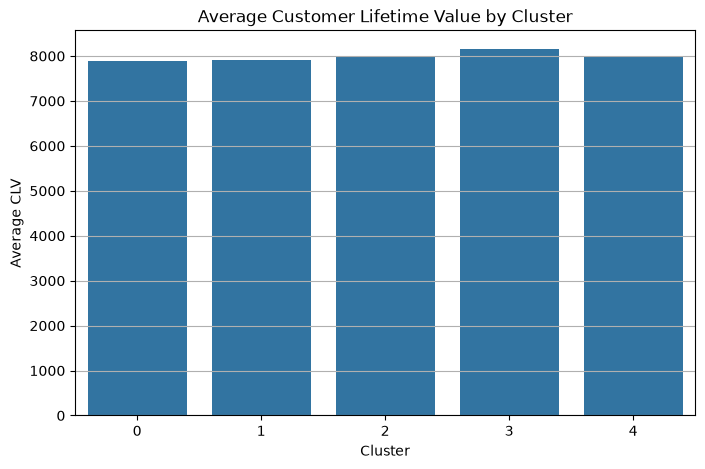

In [26]:
# ==========================================
# Average CLV by Cluster
# ==========================================

plt.figure(figsize=(8,5))

sns.barplot(
    data=df,
    x="Cluster",
    y="CLV",
    estimator="mean",
    errorbar=None
)

plt.title("Average Customer Lifetime Value by Cluster")
plt.xlabel("Cluster")
plt.ylabel("Average CLV")

plt.grid(axis="y")

plt.show()

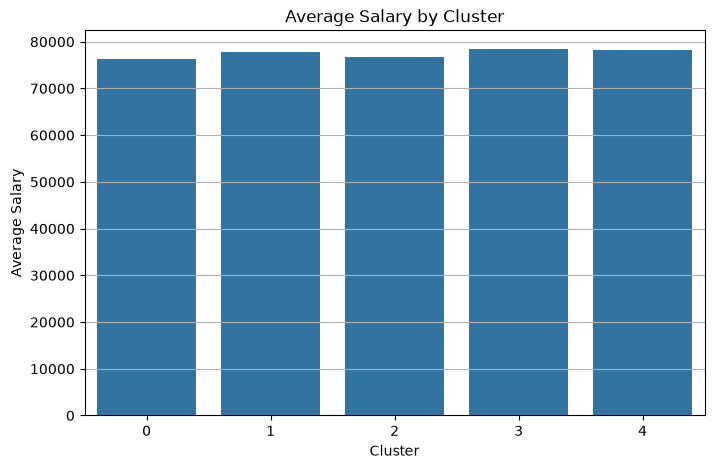

In [27]:
# ==========================================
# Average Salary by Cluster
# ==========================================

plt.figure(figsize=(8,5))

sns.barplot(
    data=df,
    x="Cluster",
    y="Salary",
    estimator="mean",
    errorbar=None
)

plt.title("Average Salary by Cluster")
plt.xlabel("Cluster")
plt.ylabel("Average Salary")

plt.grid(axis="y")

plt.show()

# Business Interpretation of Customer Segments

The final stage of the clustering analysis is to interpret each customer segment from a business perspective.

Rather than viewing clusters as numerical labels, each group is analyzed based on its demographic characteristics, customer lifetime value (CLV), income level, loyalty membership, and enrollment behavior.

This interpretation transforms the clustering results into actionable business insights that can support customer retention, personalized marketing, and loyalty program strategies.

In [28]:
# ==========================================
# Cluster Ranking Summary
# ==========================================

ranking = cluster_profile.copy()

ranking["Salary Rank"] = ranking["Salary"].rank(ascending=False).astype(int)
ranking["CLV Rank"] = ranking["CLV"].rank(ascending=False).astype(int)

display(ranking.sort_values("CLV", ascending=False))

,Salary,CLV,Enrollment Year,Enrollment Month,Salary Rank,CLV Rank
Cluster,,,,,,
3,78472.68,8159.86,2015.27,6.68,1,1
4,78167.66,7989.46,2015.27,6.59,2,2
2,76674.65,7983.30,2015.19,6.97,4,3
1,77717.19,7913.75,2015.25,6.68,3,4
0,76299.19,7878.05,2015.22,6.72,5,5


In [29]:
# Percentage of Customers in Each Cluster

cluster_percent = (
    df["Cluster"]
    .value_counts(normalize=True)
    .sort_index() * 100
)

cluster_percent = cluster_percent.round(2)

display(cluster_percent)

Cluster
0    14.36
1    32.29
2     3.09
3    23.52
4    26.74
Name: proportion, dtype: float64

In [30]:
# ==========================================
# Cluster Summary with Size and Percentages
# ==========================================

# Numerical summary
cluster_summary = df.groupby("Cluster").agg({
    "Salary": "mean",
    "CLV": "mean",
    "Enrollment Year": "mean",
    "Enrollment Month": "mean"
}).round(2)

# Cluster size
cluster_summary["Customers"] = df["Cluster"].value_counts().sort_index()

# Percentage of customers
cluster_summary["Percentage"] = (
    cluster_summary["Customers"] / len(df) * 100
).round(2)

display(cluster_summary)

,Salary,CLV,Enrollment Year,Enrollment Month,Customers,Percentage
Cluster,,,,,,
0,76299.19,7878.05,2015.22,6.72,2404,14.36
1,77717.19,7913.75,2015.25,6.68,5404,32.29
2,76674.65,7983.30,2015.19,6.97,518,3.09
3,78472.68,8159.86,2015.27,6.68,3936,23.52
4,78167.66,7989.46,2015.27,6.59,4475,26.74


In [31]:
# ==========================================
# Rank Clusters
# ==========================================

ranking = cluster_summary.copy()

ranking["Salary Rank"] = (
    ranking["Salary"]
    .rank(method="dense", ascending=False)
    .astype(int)
)

ranking["CLV Rank"] = (
    ranking["CLV"]
    .rank(method="dense", ascending=False)
    .astype(int)
)

display(ranking.sort_values("CLV", ascending=False))

,Salary,CLV,Enrollment Year,Enrollment Month,Customers,Percentage,Salary Rank,CLV Rank
Cluster,,,,,,,,
3,78472.68,8159.86,2015.27,6.68,3936,23.52,1,1
4,78167.66,7989.46,2015.27,6.59,4475,26.74,2,2
2,76674.65,7983.30,2015.19,6.97,518,3.09,4,3
1,77717.19,7913.75,2015.25,6.68,5404,32.29,3,4
0,76299.19,7878.05,2015.22,6.72,2404,14.36,5,5


In [32]:
# ==========================================
# Most Common Category in Each Cluster
# ==========================================

categorical_columns = [
    "Province",
    "City",
    "Gender",
    "Education",
    "Marital Status",
    "Loyalty Card",
    "Enrollment Type"
]

for col in categorical_columns:
    print(f"\n===== {col} =====")
    display(
        df.groupby("Cluster")[col]
        .agg(lambda x: x.mode()[0])
    )


===== Province =====


Cluster
0             Alberta
1             Ontario
2         Nova Scotia
3              Quebec
4    British Columbia
Name: Province, dtype: str


===== City =====


Cluster
0     Winnipeg
1      Toronto
2      Halifax
3     Montreal
4    Vancouver
Name: City, dtype: str


===== Gender =====


...

Cluster
0    Married
1    Married
2    Married
3    Married
4    Married
Name: Marital Status, dtype: str


===== Loyalty Card =====


Cluster
0    Star
1    Star
2    Star
3    Star
4    Star
Name: Loyalty Card, dtype: str


===== Enrollment Type =====


Cluster
0    Standard
1    Standard
2    Standard
3    Standard
4    Standard
Name: Enrollment Type, dtype: str

## Interpretation of Cluster Sizes

The final K-Means model produced five customer segments with varying sizes.

- **Cluster 1** is the largest segment, representing approximately **32.3%** of all customers.
- **Cluster 4** accounts for approximately **26.7%** of customers.
- **Cluster 3** represents approximately **23.5%** of the customer base.
- **Cluster 0** contains approximately **14.4%** of customers.
- **Cluster 2** is the smallest segment, representing only **3.1%** of customers.

The relatively small size of Cluster 2 suggests that it may represent a specialized or niche customer group, which warrants further investigation through demographic and loyalty characteristics.

## Interpretation of Numerical Characteristics

The average Salary and Customer Lifetime Value (CLV) vary across the five customer segments.

- **Cluster 3** has the highest average salary and the highest average CLV, indicating a group of high-value customers.
- **Cluster 4** ranks second for both salary and CLV, suggesting another valuable customer segment.
- **Cluster 2**, despite being the smallest cluster, has the third-highest average CLV, making it an interesting niche group.
- **Clusters 0 and 1** have relatively lower average salary and CLV, although the differences across clusters are modest.

Overall, the numerical characteristics suggest that customer segmentation is influenced not only by income and customer value but also by demographic and loyalty-related attributes.

In [33]:
display(cluster_summary)

,Salary,CLV,Enrollment Year,Enrollment Month,Customers,Percentage
Cluster,,,,,,
0,76299.19,7878.05,2015.22,6.72,2404,14.36
1,77717.19,7913.75,2015.25,6.68,5404,32.29
2,76674.65,7983.30,2015.19,6.97,518,3.09
3,78472.68,8159.86,2015.27,6.68,3936,23.52
4,78167.66,7989.46,2015.27,6.59,4475,26.74


In [34]:
# ==========================================
# Categorical Profile of Each Cluster
# ==========================================

categorical_columns = [
    "Province",
    "City",
    "Gender",
    "Education",
    "Marital Status",
    "Loyalty Card",
    "Enrollment Type"
]

categorical_profile = (
    df.groupby("Cluster")[categorical_columns]
      .agg(lambda x: x.mode()[0])
)

display(categorical_profile)

,Province,City,Gender,Education,Marital Status,Loyalty Card,Enrollment Type
Cluster,,,,,,,
0,Alberta,Winnipeg,Female,Bachelor,Married,Star,Standard
1,Ontario,Toronto,Male,Bachelor,Married,Star,Standard
2,Nova Scotia,Halifax,Male,Bachelor,Married,Star,Standard
3,Quebec,Montreal,Female,Bachelor,Married,Star,Standard
4,British Columbia,Vancouver,Female,Bachelor,Married,Star,Standard


In [35]:
# ==========================================
# Complete Cluster Summary
# ==========================================

complete_cluster_summary = pd.concat(
    [cluster_summary, categorical_profile],
    axis=1
)

display(complete_cluster_summary)

,Salary,CLV,Enrollment Year,Enrollment Month,Customers,Percentage,Province,City,Gender,Education,Marital Status,Loyalty Card,Enrollment Type
Cluster,,,,,,,,,,,,,
0,76299.19,7878.05,2015.22,6.72,2404,14.36,Alberta,Winnipeg,Female,Bachelor,Married,Star,Standard
1,77717.19,7913.75,2015.25,6.68,5404,32.29,Ontario,Toronto,Male,Bachelor,Married,Star,Standard
2,76674.65,7983.30,2015.19,6.97,518,3.09,Nova Scotia,Halifax,Male,Bachelor,Married,Star,Standard
3,78472.68,8159.86,2015.27,6.68,3936,23.52,Quebec,Montreal,Female,Bachelor,Married,Star,Standard
4,78167.66,7989.46,2015.27,6.59,4475,26.74,British Columbia,Vancouver,Female,Bachelor,Married,Star,Standard


## Interpretation of Customer Segments

The initial clustering model grouped customers into five segments. Examination of the cluster profiles shows that the segments differ slightly in terms of average salary and customer lifetime value (CLV), with **Cluster 3** having the highest average values.

However, the categorical profiles indicate that several variables—such as Education, Marital Status, Loyalty Card, and Enrollment Type—are nearly identical across all clusters. The primary distinguishing characteristics are geographic location (Province and City).

This suggests that the current feature set places considerable emphasis on geographic attributes. While geographic segmentation can be valuable for regional marketing strategies, it may not fully capture behavioral differences between customers.

To improve business relevance, a refined clustering model can be developed by reducing the influence of high-cardinality geographic variables and focusing more on customer demographics, loyalty, and value-related features.